# PV + CSP + BES + TES

A standalone microgrid demonstration. It uses 5% PNM demand, 3,000× PV availability, unscaled CSP, a 750 MWh / 150 MW battery, and 2,500 MWh-thermal / 150 MW TES.

In [1]:
from pathlib import Path
import sys
import pandas as pd

root = Path.cwd()
while not (root / 'enliten').is_dir():
    if root.parent == root: raise RuntimeError('Run from inside the ENLITEN repository.')
    root = root.parent
if str(root) not in sys.path: sys.path.insert(0, str(root))
from enliten import ChargingPath, Generation, LCOECalculator, Site, Storage, System
data_dir = root / 'examples' / 'data'

def profile(filename):
    frame = pd.read_csv(data_dir / filename)
    return pd.Series(frame['PNM'].to_numpy(float), index=pd.to_datetime(frame.iloc[:, 0], utc=True))

demand_full = profile('PNM_demand.csv')
pv_full = profile('PNM_pv_ac_1MW_av.csv')
csp_full = profile('PNM_csp_th_av.csv')
assert demand_full.index.equals(pv_full.index) and demand_full.index.equals(csp_full.index)

def build_system(start, hours=24 * 14):
    window = demand_full.index.get_loc(pd.Timestamp(start, tz='UTC'))
    load = (demand_full.iloc[window:window + hours] * 0.05).rename('load_MW')
    pv_multiplier, bes_capacity_MWh, bes_power_MW = 3_000.0, 750.0, 150.0
    tes_capacity_MWh_th, tes_power_MW_e = 2_500.0, 150.0
    pv_capex = pv_full.max() * pv_multiplier * 1_000 * 1_430
    pv_opex = pv_full.max() * pv_multiplier * 1_000 * 24
    bes_capex = bes_capacity_MWh * 1_000 * 300
    csp_tes_capex = tes_power_MW_e * 1_000 * 7_912
    site = Site('microgrid')
    csp = Generation('csp', site, csp_full.iloc[window:window + hours], 'thermal', False, False, capex=csp_tes_capex, opex=tes_power_MW_e * 1_000 * 74.6)
    pv = Generation('pv', site, pv_full.iloc[window:window + hours] * pv_multiplier, 'electric', capex=pv_capex, opex=pv_opex)
    tes = Storage('tes', site, tes_capacity_MWh_th, tes_power_MW_e, 'thermal', 'electric', 0.50, maximum_stored_energy_rate_MW=300.0, variable_opex_USD_per_MWh=3.8)
    bes = Storage('bes', site, bes_capacity_MWh, bes_power_MW, 'electric', 'electric', 0.90, maximum_stored_energy_rate_MW=bes_power_MW, capex=bes_capex, opex=0.025 * bes_capex)
    paths = [ChargingPath('csp', 'tes', 'thermal', 'thermal', 0.90, 300.0 / 0.90), ChargingPath('pv', 'bes', 'electric', 'electric', 0.90, bes_power_MW / 0.90)]
    return System(load, [tes, csp, bes, pv], paths)

system = build_system('2023-01-01')
system.timeseries.head(24)

,load_MW,grid_to_load_MWh_electric,unmet_load_MWh_electric,export_energy_MWh_electric,csp_available_MW_thermal,csp_to_load_MWh_electric,csp_to_grid_MWh_electric,csp_curtailed_MWh_thermal,pv_available_MW_electric,pv_to_load_MWh_electric,...,csp_to_tes_stored_MWh_thermal,pv_to_bes_MWh_electric,pv_to_bes_stored_MWh_electric,tes_MWh_thermal,tes_to_load_MWh_electric,tes_loss_MWh_thermal,bes_MWh_electric,bes_to_load_MWh_electric,bes_loss_MWh_electric,microgrid_POI_MW_electric
date_time,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00+00:00,84.48,0.00,0.0,0.0,0.000000,0.0,0.0,0.0,0.158849,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.00
2023-01-01 01:00:00+00:00,91.86,91.86,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.00
2023-01-01 02:00:00+00:00,92.71,92.71,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.00
2023-01-01 03:00:00+00:00,91.48,91.48,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.00
2023-01-01 04:00:00+00:00,90.35,90.35,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.00
2023-01-01 05:00:00+00:00,88.59,88.59,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.00
2023-01-01 06:00:00+00:00,86.17,86.17,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.00
2023-01-01 07:00:00+00:00,83.79,83.79,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.00
2023-01-01 08:00:00+00:00,81.62,81.62,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.00


In [2]:
system.operation_metrics()

{'operating_hours': 335,
 'load_MWh_electric': 28335.920000000002,
 'generation_to_load_MWh_electric': 9670.735269121524,
 'storage_to_load_MWh_electric': 15077.728229840575,
 'system_to_load_MWh_electric': 24748.463498962097,
 'grid_to_load_MWh_electric': 3587.456501037904,
 'unmet_load_MWh_electric': 0.0,
 'export_energy_MWh_electric': 0.0,
 'percent_load_met': 100.0,
 'percent_load_by_system': 87.33954464496686,
 'system_capex_USD': 1627380965.554332,
 'system_annual_OM_USD': 20433142.079233542,
 'csp_curtailed_MWh_thermal': 7706.6124743145665,
 'pv_curtailed_MWh_electric': 0.0,
 'load_annual_MWh_electric': [28335.920000000002],
 'system_to_load_annual_MWh_electric': [24748.463498962097],
 'grid_to_load_annual_MWh_electric': [3587.456501037904],
 'export_energy_annual_MWh_electric': [0.0],
 'annual_electricity_sales_USD': [0.0],
 'annual_electricity_purchases_USD': [0.0],
 'system_annual_VOM_USD': 1325634.906085962,
 'system_augment_USD': [0.0],
 'system_augment': [0.0]}

In [3]:
LCOECalculator.from_system(system).calculate_lcoe_metrics()

{'PVD': 0.767373270359498,
 'FCR_AT': 0.036148074230068654,
 'FCR_BT': 0.05294061134598742,
 'CRF': 0.07650022967642069,
 'NPV_cash_flow': -1473199974.49236,
 'IRR': nan,
 'payback_period': None,
 'LCOE_real_USD_kWh_BT': 4.704439402117651,
 'LCOE_real_USD_kWh_AT': 3.285844550890521}

In [4]:
summer_system = build_system('2023-07-01')
def fully_served_hours(candidate):
    return 100 * candidate.timeseries.iloc[1:]['grid_to_load_MWh_electric'].lt(1e-9).mean()
pd.Series({'January fully served hours (%)': fully_served_hours(system), 'July fully served hours (%)': fully_served_hours(summer_system)}).round(1)

January fully served hours (%)    85.4
July fully served hours (%)       96.4
dtype: float64

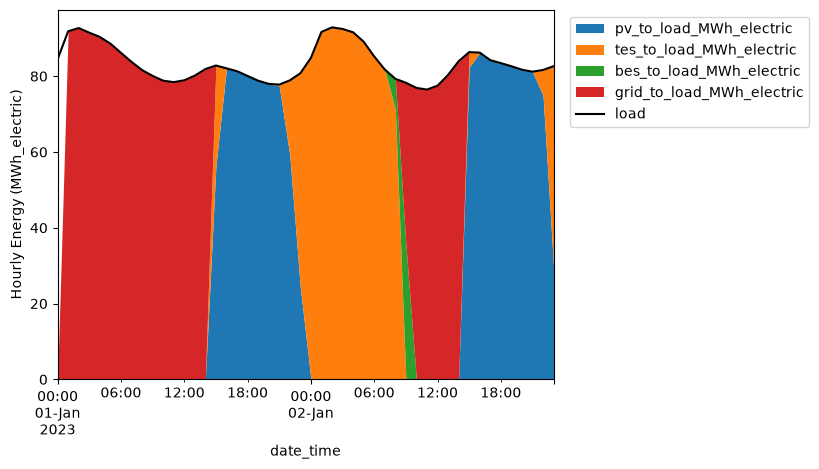

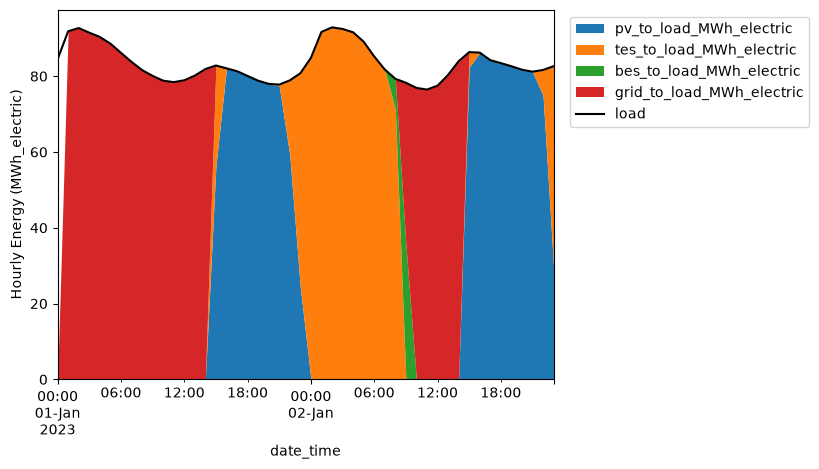

In [5]:
fig, ax = system.timeseries_plot_source(start_date=0, days=2)
fig

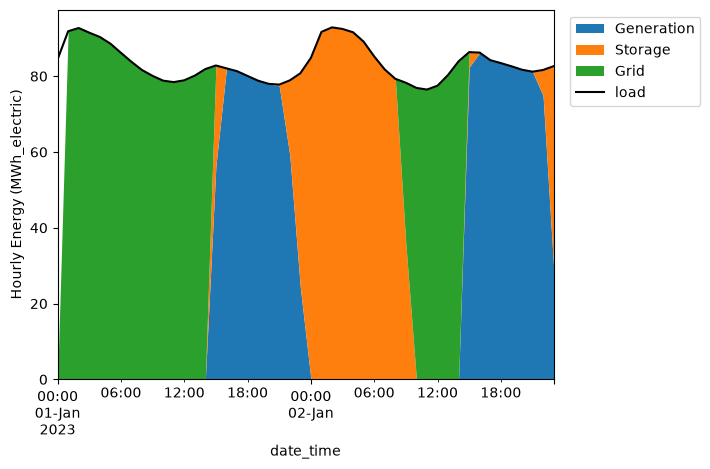

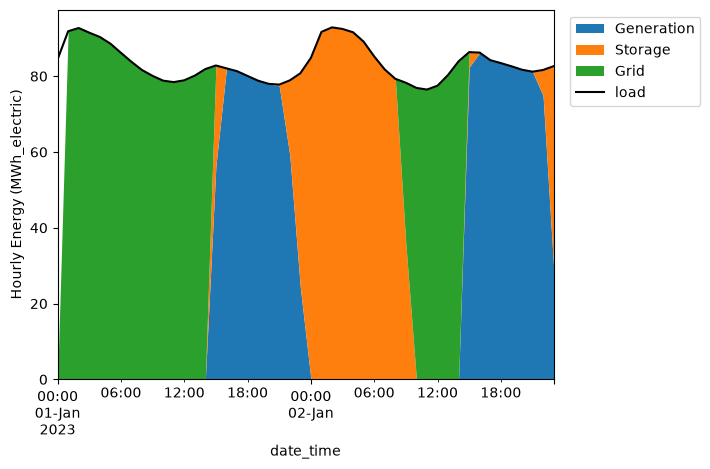

In [6]:
fig, ax = system.timeseries_plot_group(start_date=0, days=2)
fig

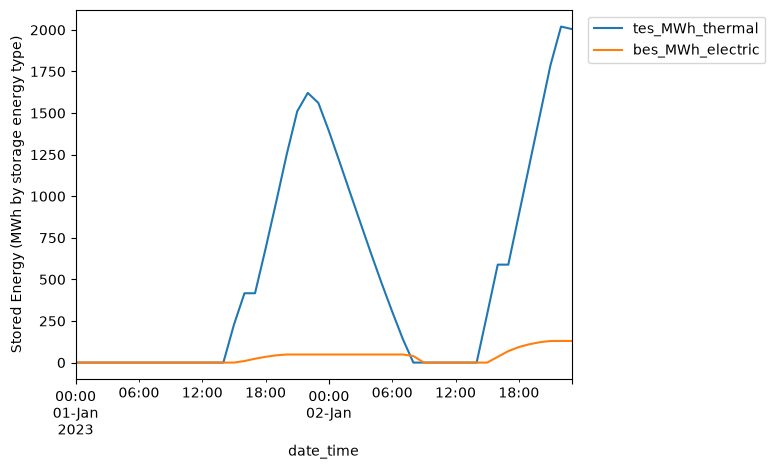

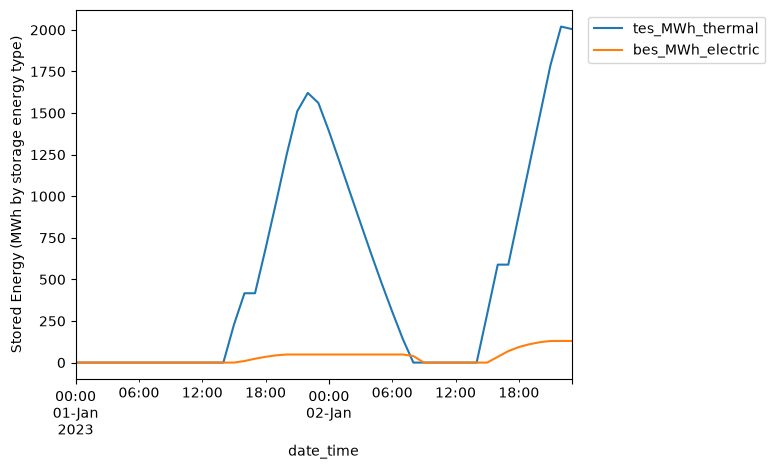

In [7]:
fig, ax = system.plot_storage_capacity(start_date=0, days=2)
fig

In [8]:
system.resilience_cases(critical_load_MW=20.0, target_hours=24, n_starts=20, seed=7)
system.resilience_summary

{'n_starts': 20,
 'pct_meets_actual': 85.0,
 'pct_meets_full': 100.0,
 'actual_reaches_end_pct': 85.0,
 'full_reaches_end_pct': 100.0,
 'tenth_pctile_actual_hrs': 0.0,
 'tenth_pctile_target_energy_actual_MWh_electric': 0.0,
 'tenth_pctile_target_energy_actual': 0.0,
 'tenth_pctile_pct_target_energy_actual': 95.83333333333334,
 'fiftieth_pctile_actual_hrs': 24.0,
 'fiftieth_pctile_target_energy_actual_MWh_electric': 0.0,
 'fiftieth_pctile_target_energy_actual': 0.0,
 'fiftieth_pctile_pct_target_energy_actual': 100.0,
 'ninetieth_pctile_actual_hrs': 24.0,
 'ninetieth_pctile_target_energy_actual_MWh_electric': 20.0,
 'ninetieth_pctile_target_energy_actual': 20.0,
 'ninetieth_pctile_pct_target_energy_actual': 100.0,
 'pct_meets_target_energy_actual': 85.0,
 'tenth_pctile_full_hrs': 24.0,
 'tenth_pctile_target_energy_full_MWh_electric': 0.0,
 'tenth_pctile_target_energy_full': 0.0,
 'tenth_pctile_pct_target_energy_full': 100.0,
 'fiftieth_pctile_full_hrs': 24.0,
 'fiftieth_pctile_target_ene